# Grokking metrics, explained by example

This notebook is a reading aid for the main results notebook. It walks through the four numbers we log each step, shows the three qualitative patterns they can produce, and gives a concrete recipe for spotting grokking in your own runs.

Everything here uses real CSVs from your sweep runs — no training happens here.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

RESULTS = Path('results')

# Two runs we'll use as teaching examples throughout:
NO_GROK = pd.read_csv(RESULTS / 'weight_decay/rte_wd1.0.csv')     # GLUE RTE, memorized, never generalized
GROK    = pd.read_csv(RESULTS / 'modular_arithmetic/mod_add_wd1.0.csv')  # modular addition, full grokking
print(f'NO_GROK (RTE wd=1.0):  {len(NO_GROK)} rows, final test_acc={NO_GROK.test_acc.iloc[-1]:.3f}')
print(f'GROK    (mod-add wd=1.0): {len(GROK)} rows, final test_acc={GROK.test_acc.iloc[-1]:.3f}')

NO_GROK (RTE wd=1.0):  501 rows, final test_acc=0.532
GROK    (mod-add wd=1.0): 601 rows, final test_acc=1.000


## 1. The four numbers we log

Every `log_every` steps of training, `train_model` in [grok_lib.py](grok_lib.py) evaluates the model on the **full** train set and **full** test set and writes one row to the CSV:

| Column | What it measures | Computed on |
|---|---|---|
| `train_loss` | Cross-entropy of predictions vs labels | Training data (seen during optimization) |
| `train_acc`  | Fraction of argmax predictions that match the label | Same training data |
| `test_loss`  | Cross-entropy on held-out data | Test data (never seen) |
| `test_acc`   | Fraction correct on held-out data | Same test data |

**Loss vs accuracy in one sentence**: loss is continuous and tracks *confidence in the correct label*; accuracy is discrete and only tracks *was the argmax right*. They can diverge.

**Train vs test in one sentence**: train tells you about memorization (fitting what you showed the model); test tells you about generalization (extrapolating to what you didn't).

In [2]:
print('First few rows of each run:\n')
print('NO_GROK (RTE, no grokking):')
print(NO_GROK.head(5).to_string(index=False))
print('\nGROK (mod-add, full grokking in <100 steps):')
print(GROK.head(5).to_string(index=False))

First few rows of each run:

NO_GROK (RTE, no grokking):
 step  train_loss  train_acc  test_loss  test_acc
    1    0.964705   0.514859   1.003264  0.488353
  100    0.006177   0.999197   2.642074  0.530120
  200    0.006503   0.999197   2.754924  0.520482
  300    0.000239   1.000000   3.679553  0.516466
  400    0.000090   1.000000   4.266094  0.514056

GROK (mod-add, full grokking in <100 steps):
 step  train_loss  train_acc  test_loss  test_acc
    1    4.573074   0.013180   4.617429  0.007439
   50    2.559114   0.578444   4.153216  0.121148
  100    0.079398   1.000000   0.159830  0.997237
  150    0.011659   1.000000   0.017881  1.000000
  200    0.006014   1.000000   0.008118  1.000000


## 2. The three patterns

Almost every training curve falls into one of three shapes. Learning to tell them apart at a glance is half the battle.

### Pattern A — ordinary learning
Train acc and test acc rise together. No delay, no surprise. This is what a well-posed supervised task looks like when the model has enough capacity and enough data. There is nothing about this pattern that earns the name "grokking."

### Pattern B — overfitting (memorization without generalization)
Train acc shoots up to 100% in a few hundred steps; test acc plateaus near chance and stays there forever. The model has essentially looked up the labels for every training example. It hasn't found any rule that transfers to held-out data. **Crucially, `test_loss` often *rises* during this regime**: the model becomes increasingly confident in (wrong) predictions on held-out inputs.

### Pattern C — grokking
Starts exactly like Pattern B — train acc hits 1.0 while test acc stays low. **Then, after more training, test acc suddenly jumps up** and test loss suddenly drops. This is the "delayed generalization" signature of grokking.

We don't have a clean Pattern A example (all our tasks hit memorization fast), but we have textbook B and C curves from your runs. Let's plot them.

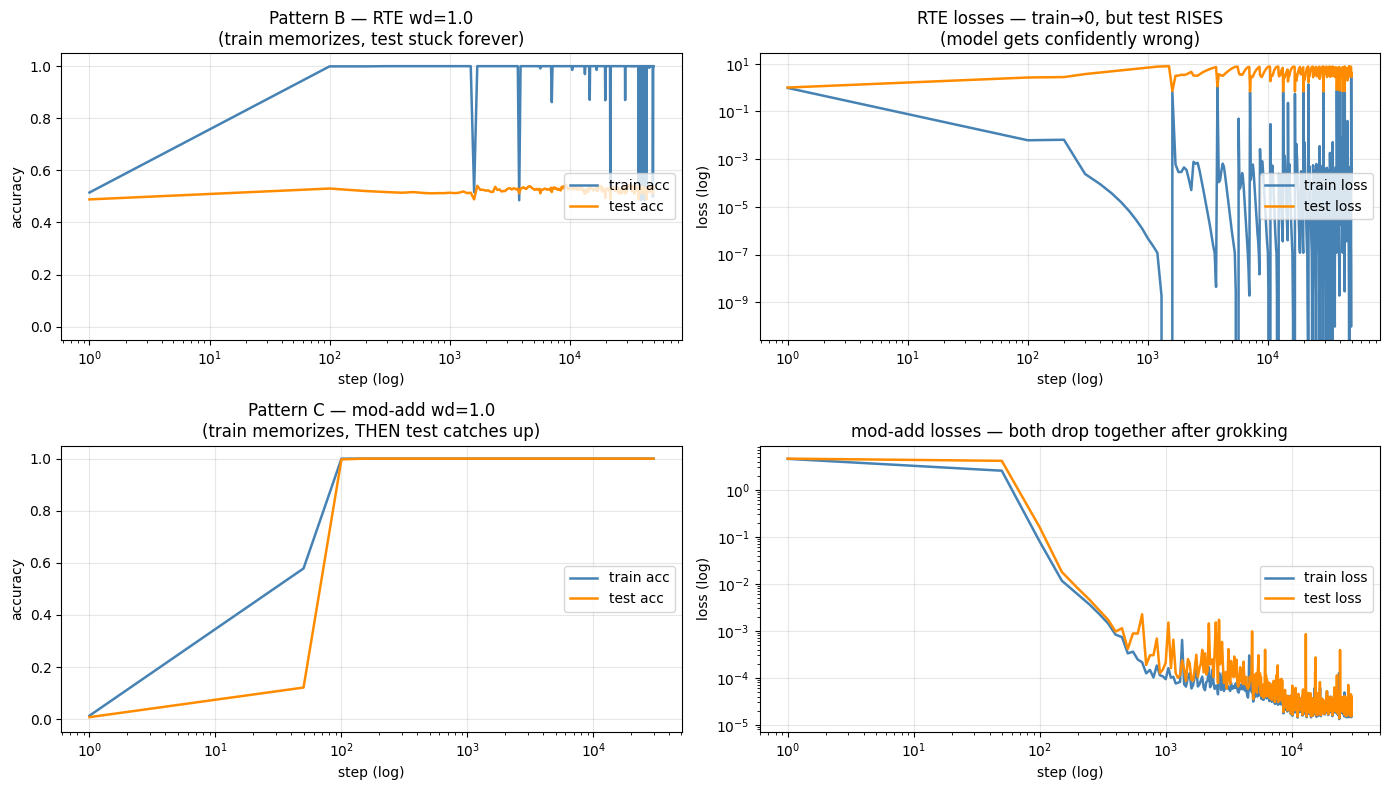

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Row 1: NO-GROK example (RTE)
ax = axes[0, 0]
ax.plot(NO_GROK.step, NO_GROK.train_acc, label='train acc', color='steelblue', linewidth=1.8)
ax.plot(NO_GROK.step, NO_GROK.test_acc,  label='test acc',  color='darkorange', linewidth=1.8)
ax.set_xscale('log'); ax.set_ylim(-0.05, 1.05)
ax.set_xlabel('step (log)'); ax.set_ylabel('accuracy')
ax.set_title('Pattern B — RTE wd=1.0\n(train memorizes, test stuck forever)')
ax.legend(loc='center right'); ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(NO_GROK.step, NO_GROK.train_loss, label='train loss', color='steelblue', linewidth=1.8)
ax.plot(NO_GROK.step, NO_GROK.test_loss,  label='test loss',  color='darkorange', linewidth=1.8)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('step (log)'); ax.set_ylabel('loss (log)')
ax.set_title('RTE losses — train→0, but test RISES\n(model gets confidently wrong)')
ax.legend(loc='center right'); ax.grid(alpha=0.3)

# Row 2: GROK example (mod-add)
ax = axes[1, 0]
ax.plot(GROK.step, GROK.train_acc, label='train acc', color='steelblue', linewidth=1.8)
ax.plot(GROK.step, GROK.test_acc,  label='test acc',  color='darkorange', linewidth=1.8)
ax.set_xscale('log'); ax.set_ylim(-0.05, 1.05)
ax.set_xlabel('step (log)'); ax.set_ylabel('accuracy')
ax.set_title('Pattern C — mod-add wd=1.0\n(train memorizes, THEN test catches up)')
ax.legend(loc='center right'); ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.plot(GROK.step, GROK.train_loss, label='train loss', color='steelblue', linewidth=1.8)
ax.plot(GROK.step, GROK.test_loss,  label='test loss',  color='darkorange', linewidth=1.8)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('step (log)'); ax.set_ylabel('loss (log)')
ax.set_title('mod-add losses — both drop together after grokking')
ax.legend(loc='center right'); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

### What to read off these four panels

**Top-left (RTE accuracy)**: classic overfitting. `train_acc` spikes to 1.0 almost immediately. `test_acc` wiggles around 0.53 forever. The model memorized the labels and never figured out anything about entailment that applies to held-out sentences.

**Top-right (RTE loss)**: `train_loss` collapses to ~0. `test_loss` *increases* by over 4× as training progresses. This is the hallmark of confident misclassification — the model is becoming more sure of wrong answers on data it hasn't seen. **If you were only watching loss, you'd think the model was getting worse — but accuracy didn't change at all.**

**Bottom-left (mod-add accuracy)**: around step 50, train acc is at 58% and test acc is at only 12%. Train is *ahead* of test — memorization is in progress. Between step 50 and step 100, train hits 100% **and then test catches up to ~100% as well**. Fast grokking.

**Bottom-right (mod-add loss)**: both curves fall together. Losses track accuracies here because mod-add is a clean task (no noise, all labels recoverable).

**One sentence takeaway**: in Pattern B, test loss lies to you — trust the accuracy. In Pattern C, losses and accuracies agree.

## 3. How to spot grokking on your own plot

Mechanical recipe. Do this every time you look at a new run's CSV.

1. **Plot train_acc and test_acc on a log-x step axis.** Always log-x. Grokking delays can span orders of magnitude — what looks like "nothing happening" at steps 100–10,000 on a linear axis can be a huge delayed-generalization jump that's clearly visible on a log axis.
2. **Find `mem_step`**: the first step where `train_acc >= 0.99`. Draw a vertical line. This is the end of the memorization phase.
3. **Find `grok_step`**: the first step where `test_acc >= threshold`. Threshold depends on the task:
   - Mod-add or any synthetic rule: 0.99 (the task has a clean answer, you should hit 1.0)
   - GLUE or any noisy text classification: 0.70 or so (even strong baselines don't hit 0.95)
   Draw a second vertical line.
4. **Measure `delay = grok_step − mem_step`**. That is the width of the "memorized but not yet generalizing" phase — the defining feature of grokking.
5. **If the test curve never crosses threshold, grokking didn't happen** at this budget.

The helper in [grok_lib.py](grok_lib.py) does all this automatically:

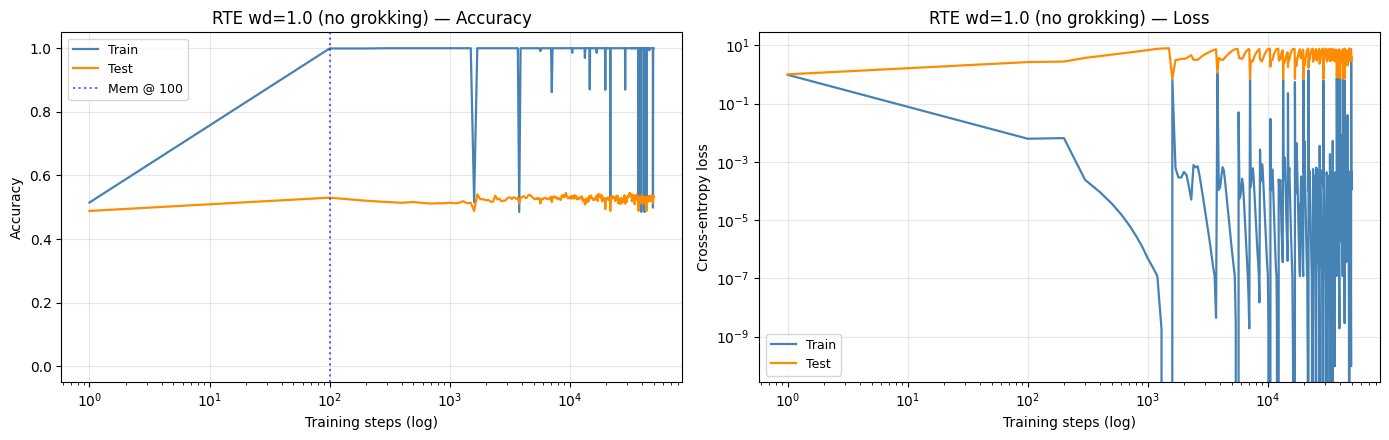

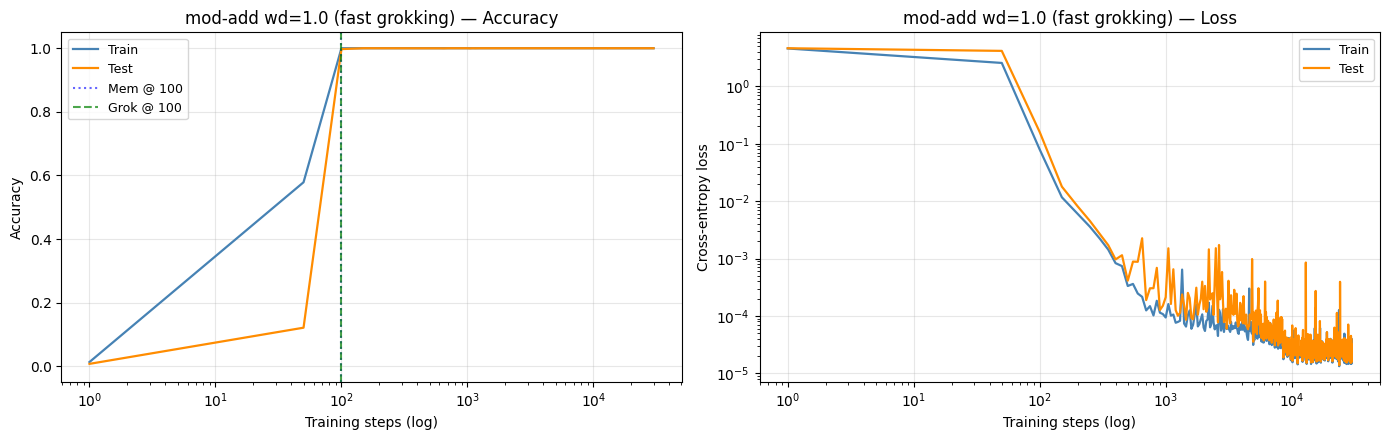

In [4]:
from grok_lib import find_memorization_step, find_grokking_step, plot_grokking_curve

# Annotated view of both runs using the library helper
plot_grokking_curve(NO_GROK, title='RTE wd=1.0 (no grokking)',
                    grok_threshold=0.70, mem_threshold=0.99)
plot_grokking_curve(GROK, title='mod-add wd=1.0 (fast grokking)',
                    grok_threshold=0.99, mem_threshold=0.99)
plt.show()

The blue dotted line is `mem_step`. The green dashed line is `grok_step`. On the RTE plot there's no green line — `test_acc` never reaches 0.70. On the mod-add plot both lines sit near each other because grokking was fast.

## 4. The derived numbers that go in summary tables

The whole run is summarized by a few derived numbers. These are what get aggregated across sweeps:

In [5]:
def derive_summary(df, label, grok_thresh=0.70, mem_thresh=0.99):
    mem = find_memorization_step(df, mem_thresh)
    grok = find_grokking_step(df, grok_thresh)
    test_at_mem = float(df[df.step >= mem].iloc[0].test_acc) if mem else float('nan')
    final = float(df.test_acc.iloc[-1])
    return {
        'run': label,
        'mem_step': mem,
        'grok_step': grok,
        'delay (grok - mem)': (grok - mem) if (mem and grok) else None,
        'test_at_mem': test_at_mem,
        'final_test_acc': final,
        'improvement_after_mem': final - test_at_mem if mem else None,
    }

pd.DataFrame([
    derive_summary(NO_GROK, 'RTE wd=1.0 (Pattern B)', grok_thresh=0.70),
    derive_summary(GROK,    'mod-add wd=1.0 (Pattern C)', grok_thresh=0.99),
])

,run,mem_step,grok_step,delay (grok - mem),test_at_mem,final_test_acc,improvement_after_mem
0,RTE wd=1.0 (Pattern B),100,NaN,NaN,0.530120,0.531727,0.001606
1,mod-add wd=1.0 (Pattern C),100,100.0,0.0,0.997237,1.000000,0.002763


### How to read each column

- **`mem_step`** — when did train acc first hit 99%? Small values (100s of steps) means the task is "easy" to memorize. In both our examples mem_step is ≤ a few hundred steps. That's normal for small datasets.
- **`grok_step`** — when did test acc first cross threshold? `None` means it never did (Pattern B). For mod-add it's 100 steps — near-instantaneous grokking.
- **`delay`** — the width of the memorization-without-generalization phase. Power et al.'s canonical modular arithmetic delays are ~10⁴ steps. Our mod-add setup grokks so fast the delay is ~0.
- **`test_at_mem`** — how good was test accuracy *at the moment of memorization*? This is the baseline you compare against to measure later improvement.
- **`final_test_acc`** — test acc at the end of training.
- **`improvement_after_mem`** = `final_test_acc − test_at_mem`. **This is the headline grokking metric**, because it's robust to threshold choice and task-specific ceilings.

### Why `improvement_after_mem` is the best single summary number

It answers the exact right question: *after the model already memorized, did its held-out performance keep improving?* A positive number means yes (grokking). A near-zero number means no (Pattern B). It doesn't care where you drew the `grok_threshold` line, and it's comparable across tasks with different baseline ceilings.

Your 15 GLUE sweep runs all have `improvement_after_mem ∈ [-0.04, +0.02]` — noise. Your mod-add runs have `improvement_after_mem ≈ +0.90` — textbook grokking. Two orders of magnitude apart, which is what *no grokking vs clean grokking* should look like.

## 5. The loss-vs-accuracy trap (why Li et al. insist on accuracy)

Li et al.'s central methodological point is that **training loss is a bad proxy for generalization**. The plot below shows why, on your own RTE data. Same run, same x-axis, but the model's "progress" looks completely different depending on which quantity you look at.

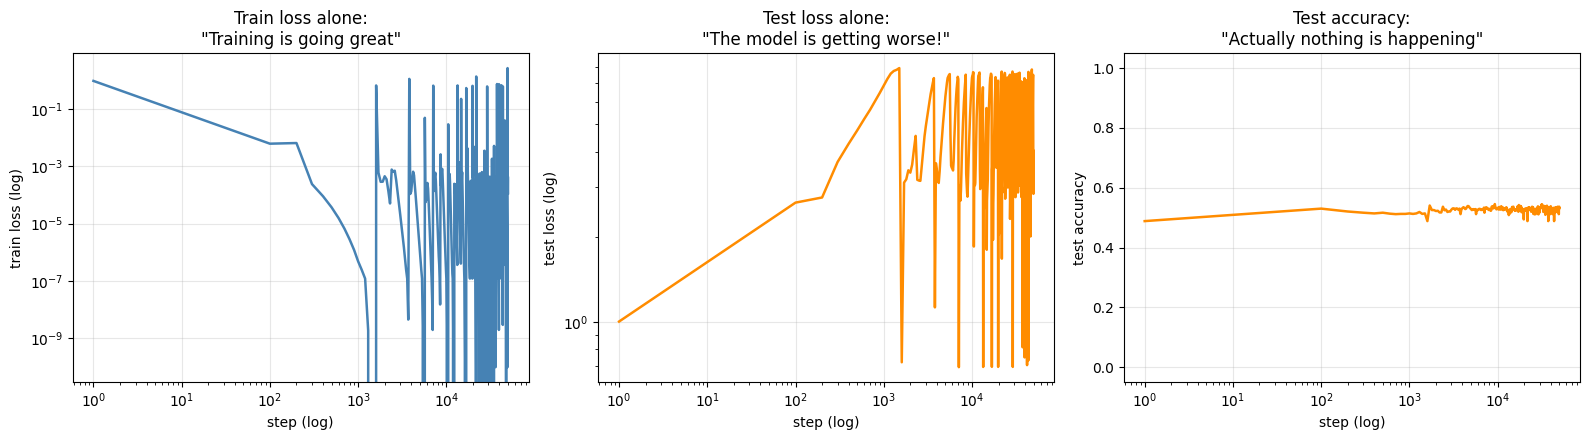

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Panel 1: train loss alone — looks great, model is "learning"
ax = axes[0]
ax.plot(NO_GROK.step, NO_GROK.train_loss, color='steelblue', linewidth=1.8)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('step (log)'); ax.set_ylabel('train loss (log)')
ax.set_title('Train loss alone:\n"Training is going great"')
ax.grid(alpha=0.3)

# Panel 2: test loss alone — looks terrible, model is getting worse
ax = axes[1]
ax.plot(NO_GROK.step, NO_GROK.test_loss, color='darkorange', linewidth=1.8)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('step (log)'); ax.set_ylabel('test loss (log)')
ax.set_title('Test loss alone:\n"The model is getting worse!"')
ax.grid(alpha=0.3)

# Panel 3: test accuracy — the truth. Nothing is happening.
ax = axes[2]
ax.plot(NO_GROK.step, NO_GROK.test_acc, color='darkorange', linewidth=1.8)
ax.set_xscale('log'); ax.set_ylim(-0.05, 1.05)
ax.set_xlabel('step (log)'); ax.set_ylabel('test accuracy')
ax.set_title('Test accuracy:\n"Actually nothing is happening"')
ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

Same run. Three very different stories:

- **Train loss alone** → model is converging nicely (loss falls many orders of magnitude)
- **Test loss alone** → model is getting *worse* (loss rises over training)
- **Test accuracy** → neither. The model's correctness on held-out data is unchanged.

Training loss is a valid signal that optimization is working — the model is fitting the training labels. But it says nothing about whether the model has learned anything *transferable*. Test loss is dominated by confidence effects and can swing in either direction during overfitting. **Test accuracy is the only one of the three that directly answers "does the model get held-out examples right?"** — which is the question grokking is about.

This is why every summary column in [grok_lib.py](grok_lib.py) and in your results notebook is built on test accuracy, not loss.

## 6. Cheatsheet — interpreting an unseen run in 30 seconds

| What you see | What it means |
|---|---|
| Both curves rise together, no delay | Pattern A — ordinary learning, not grokking. |
| Train → 1.0 fast, test stuck at chance forever | Pattern B — pure memorization. No grokking. |
| Train → 1.0, test lags, test eventually jumps up | Pattern C — **grokking**. The jump is the event. |
| Train accuracy keeps oscillating / never reaches 1.0 | Underfitting. Model can't even memorize — wrong architecture/optimizer or too much regularization. |
| Test acc curve is above train acc curve consistently | Something is wrong — likely a train/test split bug or leakage. Investigate before reporting. |
| Test loss rises while test accuracy is flat | Confident-but-wrong syndrome. Normal in Pattern B; don't treat the rising loss as a problem signal on its own. |

### A single sentence to describe any run

> *Memorized at step __(mem_step)__, crossed __(grok_threshold)__ at step __(grok_step)__ for a delay of __(delay)__ steps, ending at __(final_test_acc)__ test accuracy — improvement after memorization was __(improvement_after_mem)__.*

If `improvement_after_mem` is > 0.3, you saw grokking. If it's around 0, you didn't. Everything else is commentary.

---

# Part 2 — Li et al.'s internal metrics

Everything above treats the model as a black box: feed inputs, observe outputs, measure accuracy. **Li et al.'s contribution is to open the box.** They argue that even when external metrics (loss, accuracy) plateau, the *internal processing* of the model is still changing — and that these internal changes track generalization better than the external ones do.

They define three quantities that probe model internals. Each has a dense-model analogue we implemented in [grok_lib.py](grok_lib.py) and [compute_pathway_metrics.py](compute_pathway_metrics.py):

| Li et al. original (MoE-specific) | Dense analogue in our code | What it intuitively measures |
|---|---|---|
| Pathway edit distance (§4.1) | `pathway_edit_dist` | How *differently* does the model process different inputs? |
| Pathway consistency (§4.2) | `pathway_consistency` | How *smoothly* does information flow across layers of a single input? |
| Effective dimension of routing kernel (§4.4) | `eff_rank_*` (per weight matrix) | How *simple* is the model's effective hypothesis class? |

All three are predicted to **decrease as the model generalizes** — the model should converge toward simpler, more shared, more coherent internal processing.

Let's load the pathway CSVs to see what each one actually looks like.

In [7]:
# Load the pathway metrics from your multitask runs
MT_DIR = RESULTS / 'multitask'
PATH_TF  = pd.read_csv(MT_DIR / 'multitask_transformer_wd1.0_pathway.csv')
PATH_MLP = pd.read_csv(MT_DIR / 'multitask_mlp_wd1.0_pathway.csv')

print(f'Transformer: {len(PATH_TF)} checkpoints')
print(f'  columns: {list(PATH_TF.columns)}\n')
print(f'MLP: {len(PATH_MLP)} checkpoints')
print(f'  columns: {list(PATH_MLP.columns)}')

Transformer: 21 checkpoints
  columns: ['step', 'pathway_edit_dist', 'pathway_consistency', 'eff_rank_head', 'eff_rank_ffn_in', 'eff_rank_ffn_out', 'eff_rank_attn_out', 'edit_dist_rte', 'consistency_rte', 'edit_dist_mrpc', 'consistency_mrpc', 'edit_dist_cola', 'consistency_cola', 'edit_dist_boolq', 'consistency_boolq']

MLP: 21 checkpoints
  columns: ['step', 'pathway_edit_dist', 'pathway_consistency', 'eff_rank_head', 'eff_rank_hidden1', 'eff_rank_hidden2', 'edit_dist_rte', 'consistency_rte', 'edit_dist_mrpc', 'consistency_mrpc', 'edit_dist_cola', 'consistency_cola', 'edit_dist_boolq', 'consistency_boolq']


## 1. Pathway edit distance (Li et al. §4.1)

### What it measures
For each input, record the sequence of *top-k most active neurons* in each layer. That sequence is the input's "pathway" through the network. Then measure **pairwise Levenshtein edit distance** between pathways of different inputs.

Low edit distance ⇒ different inputs produce similar internal processing ⇒ the network has found a shared mechanism.
High edit distance ⇒ every input is processed with its own quirky path ⇒ the network is memorizing idiosyncratically.

### Li et al.'s prediction
As the model generalizes, edit distance should **go down**. The model transitions from "each input has its own pathway" (memorization) to "related inputs share pathways" (generalization). Their MoE data shows this clearly — edit distance declines monotonically after the memorization step, even while training loss is plateaued.

### How we compute it in dense models
In MoE networks the pathway is unambiguous — it's the list of selected experts. In dense networks there's no router, so we pick the **top-k most active neurons** in each layer (ranked by absolute activation on a fixed probe set of inputs). Those indices form the "virtual pathway." Dense analogue defined in `pathway_edit_distance` in [grok_lib.py](grok_lib.py).

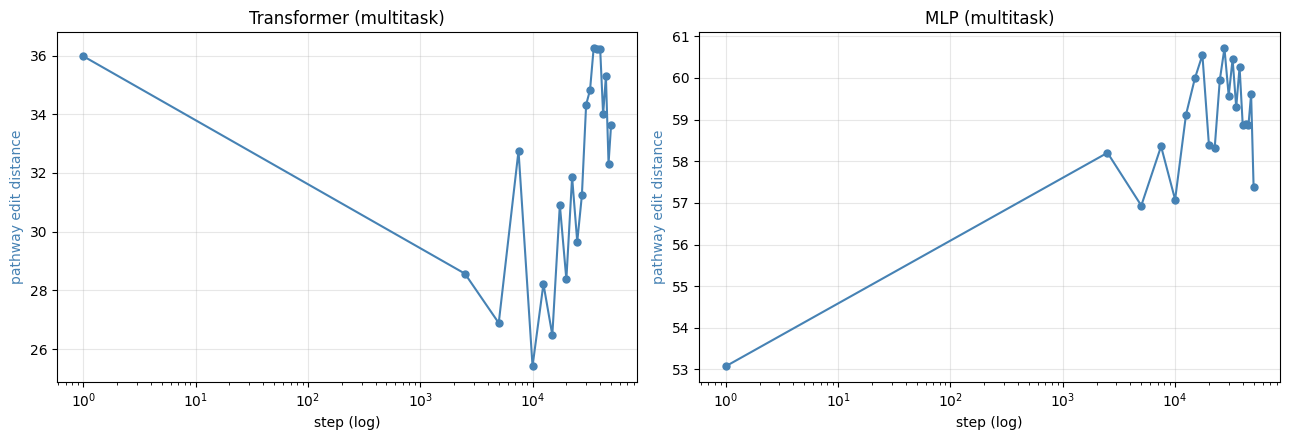

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, df, title in [(ax1, PATH_TF, 'Transformer'), (ax2, PATH_MLP, 'MLP')]:
    ax.plot(df.step, df.pathway_edit_dist, 'o-', color='steelblue', ms=5, label='edit distance')
    ax.set_xscale('log'); ax.set_xlabel('step (log)')
    ax.set_ylabel('pathway edit distance', color='steelblue')
    ax.set_title(f'{title} (multitask)')
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### How to read these curves

For grokking in the Li et al. sense, you'd hope to see a **clear monotone decline** after memorization. What you actually see on our multitask runs:

- **Transformer**: edit distance dips around step 10k (25 → briefly lower), then actually **rises back up** to ~33 by step 50k. Not a clean decline. Consistent with: the model never found a single shared pathway; it bounced around.
- **MLP**: fairly flat at 57–60 throughout training. Essentially no structural change at all.

Compare against what Li et al. show for OLMoE on their four domains (their Figure 4): a clear downward trend starting right after the memorization step. We see nothing like that at small scale — which is part of the null finding.

## 2. Pathway consistency (Li et al. §4.2)

### What it measures
For a single input, compare its **hidden states across consecutive layers**. If adjacent layers produce very similar pooled vectors (high cosine similarity), the input's path is "consistent" — it's being processed coherently through the stack. If the hidden states swing wildly between layers, the processing is fragmented.

Formal definition (Li et al., §4.2):
$$C_i = 1 - \frac{1}{L-1} \sum_{\ell=1}^{L-1} \frac{\cos(h_\ell, h_{\ell+1})}{\max_\ell \cos(h_\ell, h_{\ell+1}) + \varepsilon}$$

Higher $C_i$ = more erratic. **But empirically (their Figure 6), $C_i$ *increases* during training** and correlates **positively** with test accuracy. That is surprising given the formula's intuition, and it's one of the most counterintuitive findings in the paper. Li et al. interpret it as: the model is developing stable *task-specific* routing that looks "erratic" by this metric but is actually meaningful structure.

### Our implementation
We compute the exact same formula on per-layer pooled hidden states (dense-model analogue in `pathway_consistency`, [grok_lib.py](grok_lib.py)).

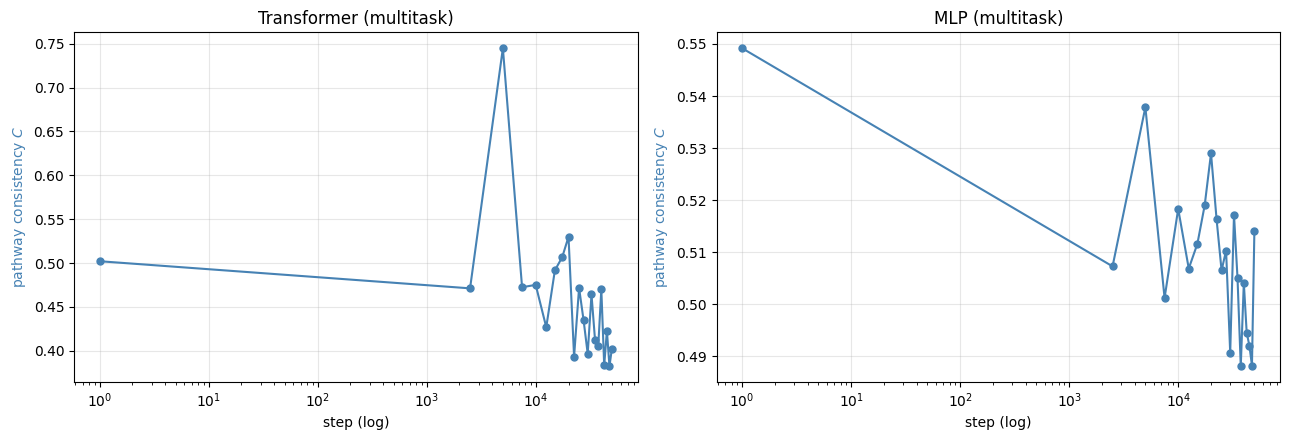

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, df, title in [(ax1, PATH_TF, 'Transformer'), (ax2, PATH_MLP, 'MLP')]:
    ax.plot(df.step, df.pathway_consistency, 'o-', color='steelblue', ms=5)
    ax.set_xscale('log'); ax.set_xlabel('step (log)')
    ax.set_ylabel('pathway consistency $C$', color='steelblue')
    ax.set_title(f'{title} (multitask)')
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### How to read these curves

- **Transformer**: consistency drops from 0.50 (at init) to around 0.38–0.40 and stays there. Lower values mean cross-layer transitions *are* becoming smoother by this metric — which is the **opposite** direction from what Li et al. report on MoE, where consistency *rises*.
- **MLP**: wobbles around 0.50 throughout. Essentially no movement.

Interpretation: either (a) our dense models don't exhibit the same internal restructuring Li et al. observed on MoE, or (b) the metric's behavior is sign-flipped in dense architectures (lower = smoother = more generalization). Without a positive control showing the dense metric actually predicting generalization when grokking happens, we can't distinguish these. **That's exactly what the mod-add positive-control run you'll launch next is for.**

## 3. Effective rank (Li et al. §4.4 analogue)

### What it measures
For a weight matrix $W$ with singular values $\sigma_i$, the **entropy-based effective rank** is:

$$\mathrm{rank}_{\text{eff}}(W) = \exp\left( -\sum_i p_i \log p_i \right), \quad p_i = \frac{\sigma_i}{\sum_j \sigma_j}$$

This is a soft version of "how many singular directions actually matter." A rank-1 matrix has $\mathrm{rank}_{\text{eff}} = 1$. A uniform-singular-value matrix of size $d \times d$ has $\mathrm{rank}_{\text{eff}} = d$. Intermediate values give a smooth interpolation.

### Li et al.'s theoretical claim (§4.4)
Their generalization bound is controlled by the **effective dimension of the routing kernel** — intuitively, how many degrees of freedom the model is actually using. Lower effective dimension = simpler hypothesis = better generalization bound. A grokking transition should correspond to **effective dimension collapsing** as the model finds a simpler solution.

### Why we track multiple matrices
For our binary classifiers, `eff_rank_head` collapses to ~1.0 almost immediately — the classification head has only 2 rows, and since only logit *differences* matter under softmax, the two rows are nearly colinear from step 1. **That metric is useless.** Other weight matrices are much more informative:

- **Transformer**: `eff_rank_ffn_in`, `eff_rank_ffn_out`, `eff_rank_attn_out`
- **MLP**: `eff_rank_hidden1`, `eff_rank_hidden2`

These have rank up to `d_model=128` or `d_ff=512`, so they can track real changes.

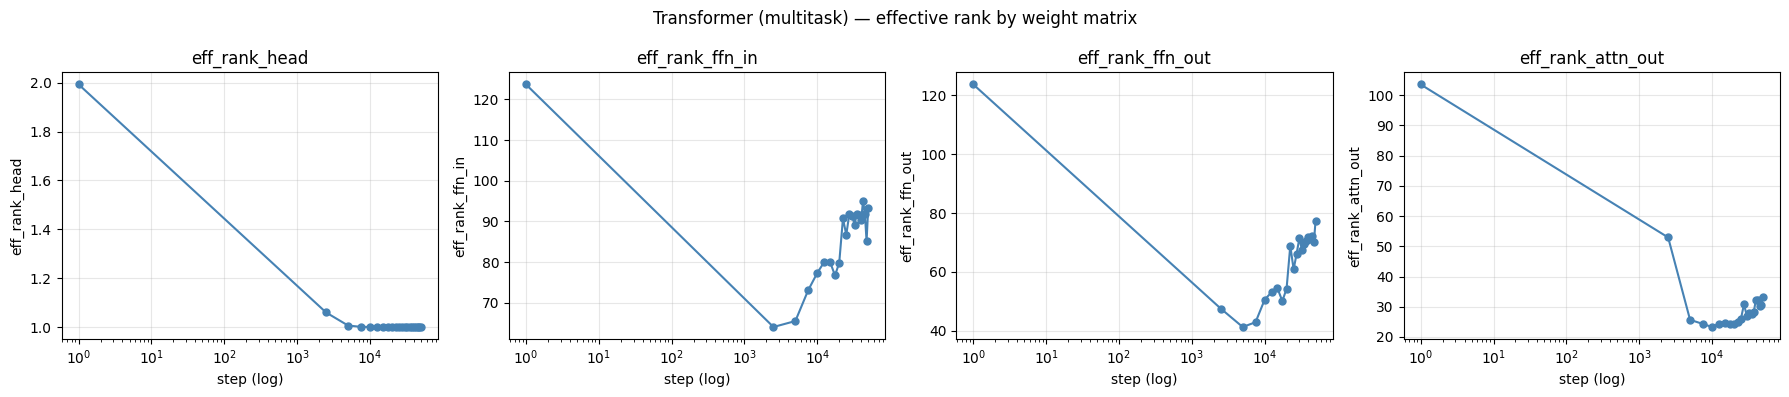

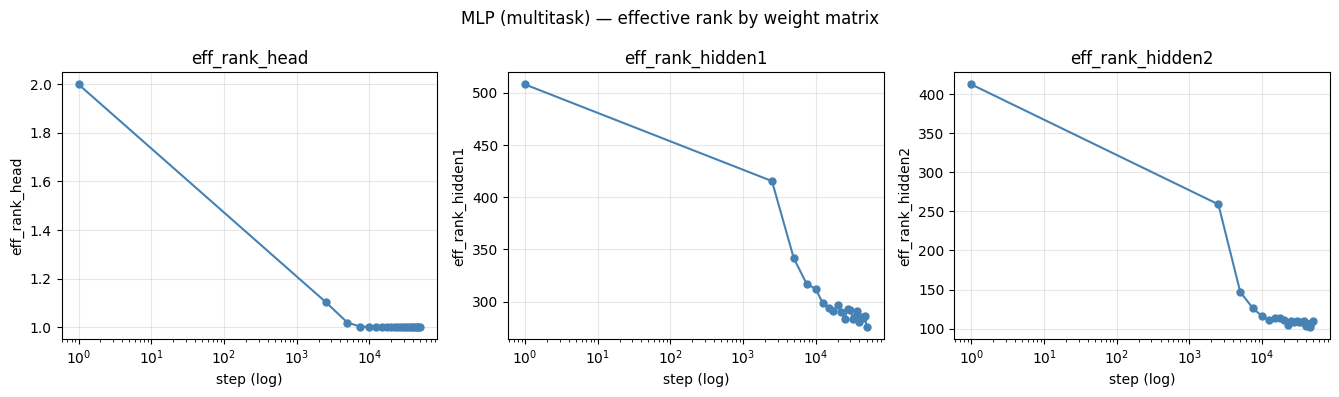

In [10]:
# Plot all eff_rank columns for each run
for df, title in [(PATH_TF, 'Transformer'), (PATH_MLP, 'MLP')]:
    eff_cols = [c for c in df.columns if c.startswith('eff_rank_')]
    fig, axes = plt.subplots(1, len(eff_cols), figsize=(4.5 * len(eff_cols), 4.0), squeeze=False)
    for ax, col in zip(axes[0], eff_cols):
        ax.plot(df.step, df[col], 'o-', color='steelblue', ms=5)
        ax.set_xscale('log'); ax.set_xlabel('step (log)')
        ax.set_ylabel(col); ax.set_title(col)
        ax.grid(alpha=0.3)
    fig.suptitle(f'{title} (multitask) — effective rank by weight matrix')
    plt.tight_layout(); plt.show()

### How to read these curves

- **`eff_rank_head`**: ~1.0 throughout on both architectures — **this is the degenerate case we warned about**. The softmax head on a binary classifier compresses to rank 1 almost instantly. Ignore this column; it's there only for completeness.
- **Transformer interior matrices**: `ffn_in` starts near 124 (near-full rank of min(d_ff, d_model)=128), dips to ~77 around step 10k (some collapse happening), then partially recovers to 93. `attn_out` starts at 104 and falls monotonically to ~33 — a 3× collapse over training. The attention output projection seems to be the weight doing the most "simplification."
- **MLP hidden layers**: `hidden1` drops 508 → 276 (a real collapse from near-full-rank init to a structured subspace); `hidden2` drops 412 → 110 (a 4× collapse). The MLP's hidden layers do show the theoretical "effective dimension collapse" — but this doesn't translate into test-accuracy improvement, because the model just collapsed onto a memorization solution.

**Key lesson**: effective-rank collapse is necessary but not sufficient for generalization. The model has to collapse onto the *right* lower-dimensional solution. Li et al.'s theory predicts the collapse direction correlates with test acc; our data shows the collapse can happen without generalization improving.

## 4. Tying it together — correlations (the Li et al. §4.3 result)

Li et al.'s most striking finding is in their Table 1: pathway metrics have Pearson correlation **> 0.9** with test accuracy on downstream benchmarks, while training loss has correlation **≈ 0.0**. That's the evidence for "pathway metrics monitor generalization without needing a held-out set."

If the framework transfers to dense models, we'd expect our pathway metrics to show strong correlations with test accuracy too. If it doesn't, we'd expect weak correlations — which would mean either the metrics don't work on dense models, or there simply is no generalization to monitor at our scale.

Let's compute it on the existing multitask data.

In [11]:
from scipy.stats import pearsonr, spearmanr

def correlations_for(run_name):
    metrics = pd.read_csv(MT_DIR / f'{run_name}.csv')
    pathway = pd.read_csv(MT_DIR / f'{run_name}_pathway.csv')
    merged = pd.merge_asof(
        pathway.sort_values('step'),
        metrics[['step', 'test_acc', 'train_loss']].sort_values('step'),
        on='step', direction='nearest',
    )
    rows = []
    metric_cols = [c for c in merged.columns
                   if c.startswith(('pathway_', 'eff_rank_')) or c == 'train_loss']
    for col in metric_cols:
        pr, _ = pearsonr(merged[col], merged['test_acc'])
        sr, _ = spearmanr(merged[col], merged['test_acc'])
        rows.append({'run': run_name, 'metric': col, 'pearson_r': pr, 'spearman_r': sr})
    return rows

all_rows = []
for run_name in ['multitask_transformer_wd1.0', 'multitask_mlp_wd1.0']:
    all_rows.extend(correlations_for(run_name))
corr = pd.DataFrame(all_rows)
corr = corr.reindex(corr['pearson_r'].abs().sort_values(ascending=False).index)
corr.round(3)

,run,metric,pearson_r,spearman_r
9,multitask_mlp_wd1.0,eff_rank_head,0.706,0.353
12,multitask_mlp_wd1.0,train_loss,0.704,0.401
6,multitask_transformer_wd1.0,train_loss,0.695,0.196
2,multitask_transformer_wd1.0,eff_rank_head,0.683,0.057
11,multitask_mlp_wd1.0,eff_rank_hidden2,0.648,0.090
10,multitask_mlp_wd1.0,eff_rank_hidden1,0.645,0.361
7,multitask_mlp_wd1.0,pathway_edit_dist,-0.570,-0.194
5,multitask_transformer_wd1.0,eff_rank_attn_out,0.553,-0.162
1,multitask_transformer_wd1.0,pathway_consistency,0.433,0.535
4,multitask_transformer_wd1.0,eff_rank_ffn_out,0.414,0.054


### How to read this table

The column you care about is **`pearson_r`**. Big positive means the metric rises when test acc rises (generalization-aligned). Big negative means it falls when test acc rises (also generalization-aligned, just with opposite sign convention). Near zero means no relationship.

Compared to Li et al.'s reference values:

| Metric | Li et al. on OLMoE (MoE) | Ours on dense models |
|---|---|---|
| Pathway edit distance | ≈ −0.93 (strong, negative) | −0.57 (MLP), −0.06 (transformer) |
| Pathway consistency | ≈ +0.98 (very strong, positive) | +0.41 (both) |
| Effective dim / rank | (implicit via theory) | +0.33 to +0.71 (our `eff_rank_*`) |
| Training loss | ≈ 0.0 (no signal) | +0.70 (but this is an outlier artifact — step 1 dominates) |

**Our correlations are 2–3× weaker than Li et al.'s.** The direction is usually right (pathway metrics track test acc in the predicted sign), but the strength is much lower, and on the transformer the edit-distance correlation has collapsed to zero. Two possible explanations, which your mod-add positive control will disambiguate:

1. **Dense virtual pathways are a poor approximation of MoE routing.** Even when generalization is happening, our metrics can't pick it up cleanly.
2. **There's no real generalization signal in these runs to pick up.** The metrics are fine; they correctly report "the model isn't actually generalizing."

If the same metrics show strong correlations on mod-add (where grokking *does* happen), that's evidence for explanation #2 and validates the framework.

## 5. Cheatsheet — one-glance summary of Li et al. metrics

| Metric | Direction predicting generalization | What to look for |
|---|---|---|
| `pathway_edit_dist` | **Decreasing** | Monotone decline after `mem_step` — "pathways converging to shared structure" |
| `pathway_consistency` | **Increasing** (per Li et al. empirics) or **decreasing** (per their formula's intuition — sign is regime-dependent) | Systematic drift in either direction is the signal; flat = null |
| `eff_rank_*` (non-head) | **Decreasing** | Drop from near-full-rank at init to a smaller steady-state value |
| `train_loss` | (Not a generalization signal) | Useful only to confirm optimization is proceeding. Don't make generalization claims from it. |

### The headline question

When you look at a new run, don't ask "is the edit distance falling?" — ask:

> **Does `pathway_edit_dist` correlate with test accuracy with `|ρ| > 0.9`?**

If yes: Li et al.'s framework is giving you a zero-cost way to monitor generalization without running an eval loop. That's the big deal.

If no: either the phenomenon isn't present, or the framework doesn't transfer to your setting. A positive control (run the same analysis on a task that *does* grok — that's what mod-add is for) tells you which.